[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yryo1005/identity-anonymizer/blob/master/notebooks/06_train_attribute_nn_anonymizer.ipynb)

Colab上で開く場合，このnotebookはColab用の環境構築セルを含まないため，先に [demo.ipynb](../demo.ipynb) の「1. Python環境のセットアップ」「2. リポジトリの取得と依存関係のインストール」と同様の手順を実行しておくこと．環境構築を含めて手軽に匿名化を試すだけであれば，[demo.ipynb](../demo.ipynb) の利用を推奨する．

# 06: 属性入力型Anonymizer(「従来手法2」)の学習

`Anonymizer` は，出力(匿名化後の顔ベクトル，形状 `(B, 512)`)は固定だが，入力の形式・形状は
サブクラスごとに自由に設計できる．本notebookでは，その具体例として
`references/` の予稿・発表資料で紹介されている「従来手法2」に相当する
`AttributeNNAnonymizer` を実装・学習する．

`VAEAnonymizer` がターゲットの顔画像から計算したArcFace顔ベクトルそのものを入力とするのに
対し，`AttributeNNAnonymizer` は性別・年齢・人種といった**属性**を入力とし，ArcFaceの
顔ベクトルを近似的に出力するNNである．学習は，UTKFaceの各顔画像 $ X_n $ とその属性 $ I_n $
の組を用いて，以下の目的関数を最小化することで行う．

$$
\arg\min_{NN} \frac{1}{N} \sum_{n=1}^{N} \| \mathrm{ArcFace}(X_n) - NN(I_n) \|_2
$$

なお，本モデルは「ターゲットの属性を事前に取得しておく必要がある」という，予稿でも指摘されて
いる従来手法の課題をそのまま引き継いでいる．本notebookは，`Anonymizer` インターフェースが
入力の異なるモデルを問題なく扱えることを示すための実装例である．サブクラスの実装方法の詳細は
`document.md` を参照すること．


In [1]:
import os
import sys

# notebooks/ から見て1階層上がリポジトリルート
REPO_ROOT = os.path.dirname(os.getcwd())
sys.path.insert(0, os.path.join(REPO_ROOT, "src"))
os.chdir(REPO_ROOT)

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

_jp_font_path = "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
if os.path.exists(_jp_font_path):
    fm.fontManager.addfont(_jp_font_path)
    plt.rcParams["font.family"] = "Noto Sans CJK JP"
    plt.rcParams["axes.unicode_minus"] = False


In [2]:
from identity_anonymizer.faceswap import load_ghost_models
from identity_anonymizer.data import build_attribute_embedding_dataset

models = load_ghost_models()


/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/kornia/augmentation/augmentation.py:1830: DeprecationWarning: GaussianBlur is no longer maintained and will be removed from the future versions. Please use RandomGaussianBlur instead.
  warnings.warn(


input mean and std: 127.5 127.5
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/glintr100.onnx recognition
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/scrfd_10g_bnkps.onnx detection
set det-size: (640, 640)
loading /home/yryo1005/workspace/identity-anonymizer/weights/ghost/2d106det 0
input mean and std: 127.5 127.5
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/glintr100.onnx recognition
find model: /home/yryo1005/workspace/identity-anonymizer/weights/ghost/antelope/scrfd_10g_bnkps.onnx detection
set det-size: (640, 640)


[13:36:32] ../src/nnvm/legacy_json_util.cc:208: Loading symbol saved by previous version v1.5.0. Attempting to upgrade...
[13:36:32] ../src/nnvm/legacy_json_util.cc:216: Symbol successfully upgraded!
[13:36:32] ../src/base.cc:79: cuDNN lib mismatch: linked-against version 8302 != compiled-against version 8101.  Set MXNET_CUDNN_LIB_CHECKING=0 to quiet this warning.


In [3]:
IMAGE_DIR = "data/utkface_sample"  # UTKFace全件を使う場合は "data/UTKFace" 等に変更する
OUTPUT_DIR = "data/processed_attribute_demo"

attributes, embeddings, train_indices, test_indices = build_attribute_embedding_dataset(
    image_dir=IMAGE_DIR,
    models=models,
    output_dir=OUTPUT_DIR,
    test_size=0.1,
    seed=0,
)

print(f"総サンプル数: {len(embeddings)} (学習用: {len(train_indices)}, 検証用: {len(test_indices)})")
print(f"属性(age, gender, race)の例: {attributes[0]}")


総サンプル数: 467 (学習用: 420, 検証用: 47)
属性(age, gender, race)の例: [100.   1.   0.]


## AttributeNNAnonymizerの学習

`train_attribute_nn_anonymizer` は，`AttributeNNAnonymizer` をインスタンス化し，上記の
目的関数で学習する．検証用データに対するL2ノルム損失が最良のエポックの重みを保存する．


In [4]:
from identity_anonymizer.anonymizers import train_attribute_nn_anonymizer

TARGET_WEIGHT_PATH = "weights/anonymizers/attribute_nn/attribute_nn.pt"

history = train_attribute_nn_anonymizer(
    target_weight_path=TARGET_WEIGHT_PATH,
    attributes=attributes,
    embeddings=embeddings,
    train_indices=train_indices,
    test_indices=test_indices,
    epochs=50,
    batch_size=32,
    hidden_dim=256,
    seed=0,
    verbose=True,
)


epoch 0: train_loss=22.7286, test_loss=22.4836


epoch 1: train_loss=22.6539, test_loss=22.4121


epoch 2: train_loss=22.5322, test_loss=22.4148


epoch 3: train_loss=22.4625, test_loss=22.4097


epoch 4: train_loss=22.3960, test_loss=22.4414


...

epoch 46: train_loss=21.7575, test_loss=22.5830


epoch 47: train_loss=21.7489, test_loss=22.5791


epoch 48: train_loss=21.7389, test_loss=22.5636


epoch 49: train_loss=21.7296, test_loss=22.5815


epoch 50: train_loss=21.7201, test_loss=22.5940


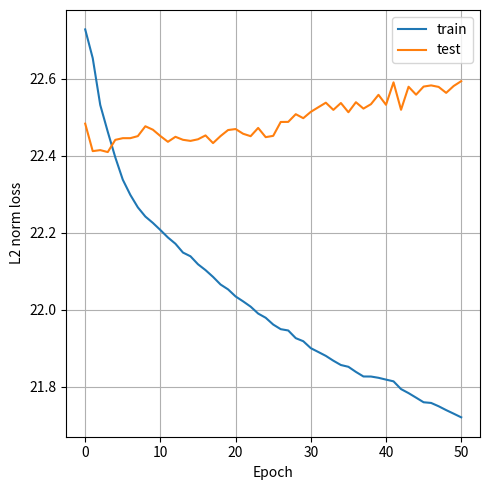

In [5]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(1, 1, 1)
ax.plot(history["train_loss"], label="train")
ax.plot(history["test_loss"], label="test")
ax.set_xlabel("Epoch")
ax.set_ylabel("L2 norm loss")
ax.legend()
ax.grid()
fig.tight_layout()
fig.savefig("weights/anonymizers/attribute_nn/attribute_nn_history.png")
plt.show()


## パイプラインへの差し替えデモ

学習済みの `AttributeNNAnonymizer` を `FaceAnonymizerPipeline` に差し替え，属性のみから
顔を匿名化できることを確認する．ターゲット画像そのものは使わず，年齢・性別・人種の指定のみで
匿名化後の顔ベクトルが得られる点が `VAEAnonymizer` との違いである．

以下では，`sample_images/beckham.jpg` を土台(向き・表情の情報源)として使いつつ，
`AttributeNNAnonymizer` が生成した顔ベクトルへ変換する．


/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  if spsp is not None and isinstance(source_array, spsp.csr.csr_matrix):
[13:36:42] ../src/operator/nn/./cudnn/./cudnn_algoreg-inl.h:96: Running performance tests to find the best convolution algorithm, this can take a while... (set the environment variable MXNET_CUDNN_AUTOTUNE_DEFAULT to 0 to disable)
/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` namespace, the `scipy.sparse.csr` namespace is deprecated.
  if spsp is not None and isinstance(source_array, spsp.csr.csr_matrix):
/home/yryo1005/.conda/envs/py39_dex_ghost_2/lib/python3.9/site-packages/mxnet/ndarray/utils.py:141: DeprecationWarning: Please use `csr_matrix` from the `scipy.sparse` n

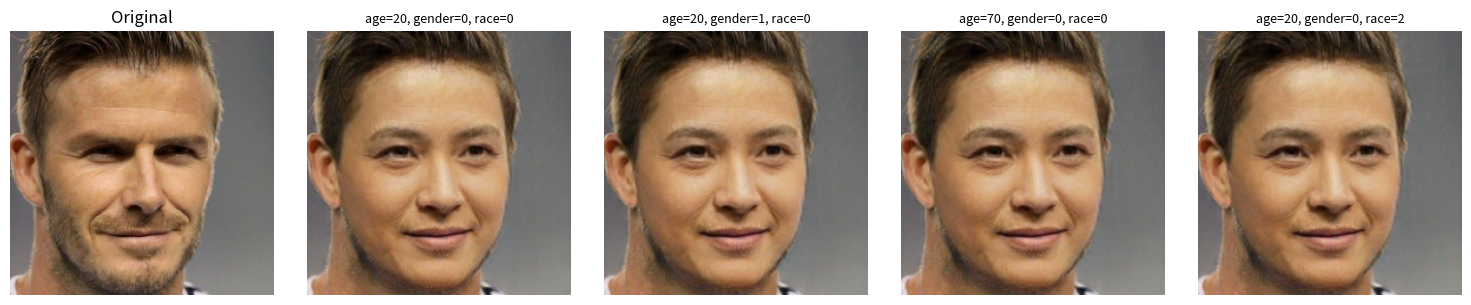

In [6]:
from identity_anonymizer.anonymizers import get_anonymizer
from identity_anonymizer.faceswap import FaceAnonymizerPipeline

attribute_anonymizer = get_anonymizer("attribute_nn", weight_path=TARGET_WEIGHT_PATH, hidden_dim=256)
pipeline = FaceAnonymizerPipeline(models, attribute_anonymizer)

TARGET_IMAGE_PATH = "sample_images/beckham.jpg"
ATTRIBUTE_EXAMPLES = [
    {"age": 20, "gender": 0, "race": 0},
    {"age": 20, "gender": 1, "race": 0},
    {"age": 70, "gender": 0, "race": 0},
    {"age": 20, "gender": 0, "race": 2},
]

import cv2
from utils.inference.image_processing import crop_face

original_full = cv2.imread(TARGET_IMAGE_PATH)
original_face = crop_face(original_full, pipeline.models.app, pipeline.crop_size)[0]

fig, axes = plt.subplots(1, len(ATTRIBUTE_EXAMPLES) + 1, figsize=(3 * (len(ATTRIBUTE_EXAMPLES) + 1), 3))

axes[0].imshow(original_face[:, :, ::-1])
axes[0].set_title("Original")
axes[0].axis("off")

for ax, attrs in zip(axes[1:], ATTRIBUTE_EXAMPLES):
    face_image, _ = pipeline.anonymize_image(TARGET_IMAGE_PATH, anonymizer_input=attrs)
    ax.imshow(face_image[:, :, ::-1])
    ax.set_title(f"age={attrs['age']}, gender={attrs['gender']}, race={attrs['race']}", fontsize=9)
    ax.axis("off")

fig.tight_layout()
os.makedirs("outputs", exist_ok=True)
fig.savefig("outputs/attribute_nn_comparison.png")
plt.show()


指定した属性(年齢・性別・人種)を変化させることで，生成される架空の顔がそれに応じて変化する
ことを確認できる．一方，`VAEAnonymizer` と異なり，ターゲットの属性を事前に(何らかの方法で)
取得する必要がある点には注意すること．
